# Model Comparison

ELPD-Based Model Evaluation

We calculated the expected log pointwise predictive density (ELPD) for each model to summarize its expected out-of-sample predictive performance. Differences in ELPD should be interpreted alongside their standard errors, which quantify uncertainty in the estimated predictive performance.

In [ ]:
from cmdstanpy import CmdStanModel
import arviz as az
import pickle as pkl
import os
import xarray as xr
import numpy as np

In [2]:
#Change the working directory
import os
os.chdir('/home/apoorva/Desktop/MZB-new-analysis')

In [3]:
#open the data file
with open('data/New output (pkl)/Steady State/Unified_model/T1_varyinflux_time_infprior.pkl', 'rb') as f:
    fit_1 = pkl.load(f)

with open('data/New output (pkl)/Steady State/Unified_model/T2_varyinflux_time_infprior.pkl', 'rb') as f:
    fit_2 = pkl.load(f)
    
with open('data/New output (pkl)/Steady State/Unified_model/T1_varydivision_decfunc_time_infprior.pkl', 'rb') as f:
    fit_3 = pkl.load(f)

with open('data/New output (pkl)/Steady State/Unified_model/T2_varydivision_decfunc_time_infprior.pkl', 'rb') as f:
    fit_4 = pkl.load(f)
    
with open('data/New output (pkl)/Steady State/Unified_model/T1_varyloss_time_infprior.pkl', 'rb') as f:
    fit_5 = pkl.load(f)

with open('data/New output (pkl)/Steady State/Unified_model/T2_varyloss_time_infprior.pkl', 'rb') as f:
    fit_6 = pkl.load(f)
    
with open('data/New output (pkl)/Steady State/Unified_model/T1_varyinflux_density_infprior.pkl', 'rb') as f:
    fit_7 = pkl.load(f)

with open('data/New output (pkl)/Steady State/Unified_model/T2_varyinflux_density_infprior.pkl', 'rb') as f:
    fit_8 = pkl.load(f)

with open('data/New output (pkl)/Steady State/Unified_model/T1_varydivision_density_infprior.pkl', 'rb') as f:
    fit_9 = pkl.load(f)

with open('data/New output (pkl)/Steady State/Unified_model/T2_varydivision_density_infprior.pkl', 'rb') as f:
    fit_10 = pkl.load(f)
    
with open('data/New output (pkl)/Steady State/Unified_model/T1_varyloss_density_infprior.pkl', 'rb') as f:
    fit_11 = pkl.load(f)

with open('data/New output (pkl)/Steady State/Unified_model/T2_varyloss_density_infprior.pkl', 'rb') as f:
    fit_12 = pkl.load(f)

with open('data/New output (pkl)/Steady State/Unified_model/T1_varyinflux_divisiondensity_infprior.pkl', 'rb') as f:
    fit_13 = pkl.load(f)

with open('data/New output (pkl)/Steady State/Unified_model/T2_varyinflux_divisiondensity_infprior.pkl', 'rb') as f:
    fit_14 = pkl.load(f)

with open('data/New output (pkl)/Steady State/Unified_model/T2_varyinflux_lossdensity_infprior.pkl', 'rb') as f:
    fit_15 = pkl.load(f)

with open('data/New output (pkl)/Steady State/Unified_model/T1_varyinflux_lossdensity_infprior.pkl', 'rb') as f:
    fit_16 = pkl.load(f)


# data_file = os.path.join('/home/apoorva/Desktop/work/MZ_analysis/data/data.json')

In [4]:
# Convert the fit objects to arviz InferenceData objects with log_likelihoods array
# Dictionary to store idata objects
idata_dict = {}

for i in range(1, 17):
	fit_var = eval(f"fit_{i}")  # Dynamically access fit_1, fit_2, ..., fit_22
	idata_dict[f"idata_{i}"] = az.from_cmdstanpy(fit_var, log_likelihood={"log_lik_Mz": "log_lik_Mz", "log_lik_Nfd": "log_lik_Nfd", "log_lik_Kid": "log_lik_Kid", "log_lik_Kih": "log_lik_Kih"})

# Dynamically assign idata_1, idata_2, ..., idata_22 for compatibility with later cells
globals().update(idata_dict)

In [ ]:
updated_idata_dict = {}

for i in range(1, 17):
    idata_i = globals()[f"idata_{i}"]

    ll_mz  = np.asarray(idata_i.log_likelihood["log_lik_Mz"].values)   # (chain, draw, n_mz)
    ll_nfd = np.asarray(idata_i.log_likelihood["log_lik_Nfd"].values)  # (chain, draw, n_nfd)
    ll_kid = np.asarray(idata_i.log_likelihood["log_lik_Kid"].values)  # (chain, draw, n_kid)
    ll_kih = np.asarray(idata_i.log_likelihood["log_lik_Kih"].values)  # (chain, draw, n_kih)

    # combine pointwise log-likelihoods across observations
    combined_lik = np.concatenate([ll_mz, ll_nfd, ll_kid, ll_kih], axis=-1)

    chain_coord = idata_i.log_likelihood["log_lik_Mz"].coords["chain"].values
    draw_coord  = idata_i.log_likelihood["log_lik_Mz"].coords["draw"].values
    obs_coord   = np.arange(combined_lik.shape[-1])

    updated_log_likelihood = idata_i.log_likelihood.copy()
    updated_log_likelihood["combined_log_lik"] = xr.DataArray(
        combined_lik,
        dims=("chain", "draw", "obs_id"),
        coords={"chain": chain_coord, "draw": draw_coord, "obs_id": obs_coord},
    )

    updated_idata_dict[f"idata_{i}"] = az.InferenceData(
        posterior=idata_i.posterior,
        log_likelihood=updated_log_likelihood,
        sample_stats=idata_i.sample_stats,
    )

globals().update(updated_idata_dict)


In [9]:
model_dict = {f"model_{i}": globals()[f"idata_{i}"] for i in range(1, 17)}
comparison_combined = az.compare(model_dict, var_name="combined_log_lik", method="BB-pseudo-BMA")
print(comparison_combined)

/home/apoorva/Desktop/MZB-new-analysis/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/apoorva/Desktop/MZB-new-analysis/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/apoorva/Desk

          rank     elpd_loo        p_loo    elpd_diff        weight  \
model_13     0   -27.260094    12.494459     0.000000  4.155468e-01   
model_14     1   -27.318634    12.842343     0.058540  4.000964e-01   
model_15     2   -28.980839    11.885059     1.720745  1.186273e-01   
model_16     3   -30.371937    11.946440     3.111843  6.456085e-02   
model_6      4   -39.254763    11.943625    11.994669  6.634380e-05   
model_2      5   -41.317239    12.384183    14.057145  9.659329e-04   
model_5      6   -42.462085    11.795045    15.201991  1.007114e-05   
model_1      7   -43.861540    12.029234    16.601446  1.075407e-04   
model_10     8   -57.826861    12.802003    30.566767  1.590255e-05   
model_9      9   -59.744220    15.306500    32.484126  2.792217e-06   
model_12    10   -68.246453    16.766278    40.986358  7.132383e-11   
model_11    11   -68.578908    15.224856    41.318813  3.819363e-11   
model_8     12   -77.102769    10.743276    49.842675  3.572201e-13   
model_

/home/apoorva/Desktop/MZB-new-analysis/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


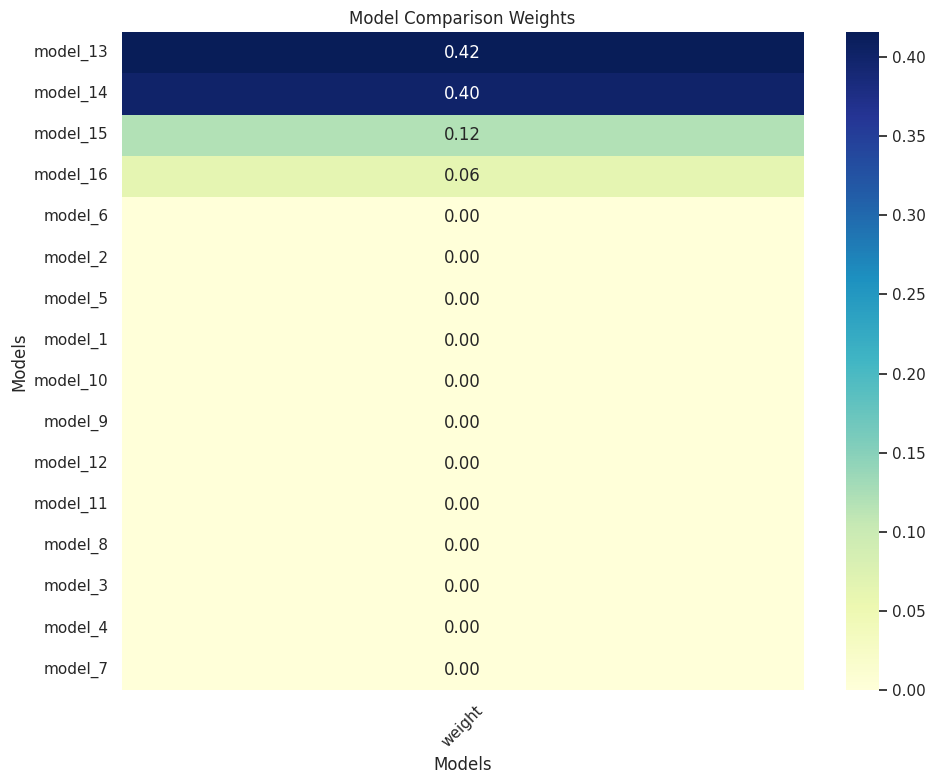

In [10]:
# Create heatmap of the comparison results based on weights 

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set(style="whitegrid")
# Convert the comparison results to a DataFrame
comparison_df = pd.DataFrame(comparison_combined)
# Create a heatmap using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(comparison_df[['weight']], annot=True, cmap="YlGnBu", cbar=True, fmt=".2f")
plt.title("Model Comparison Weights")
plt.xlabel("Models")
plt.ylabel("Models")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()